# SHAP Analysis 


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings('ignore')

shap.initjs()

## 1. data loadimg

In [2]:
def create_features(df):
    df = df.copy()
    
    df['accommodates_per_bedroom'] = df['accommodates'] / (df['bedrooms'] + 1)
    df['accommodates_per_bathroom'] = df['accommodates'] / (df['bathrooms_clean'] + 1)
    df['bedrooms_per_bathroom'] = df['bedrooms'] / (df['bathrooms_clean'] + 1)
    df['beds_per_bedroom'] = df['beds'] / (df['bedrooms'] + 1)
    df['total_rooms'] = df['bedrooms'] + df['bathrooms_clean']
    df['space_efficiency'] = df['accommodates'] / (df['bedrooms'] + df['beds'] + 1)
    
    review_cols = ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
                   'review_scores_checkin', 'review_scores_communication', 
                   'review_scores_location', 'review_scores_value']
    existing_review_cols = [col for col in review_cols if col in df.columns]
    if existing_review_cols:
        for col in existing_review_cols:
            df[col] = df[col].fillna(df[col].median())
        df['review_composite'] = df[existing_review_cols].mean(axis=1)
        df['review_variance'] = df[existing_review_cols].std(axis=1)
    
    df['host_quality'] = (
        df['host_is_superhost'].fillna(0) * 3 +
        df['host_identity_verified'].fillna(0) * 2 +
        df['host_has_profile_pic'].fillna(0) * 1 +
        (df['host_response_rate'].fillna(0) / 100) +
        (df['host_acceptance_rate'].fillna(0) / 100)
    )
    
    df['booking_flexibility'] = 1 / (df['minimum_nights'] + 1)
    df['long_term_friendly'] = (df['minimum_nights'] >= 30).astype(int)
    
    if 'amenities_count' in df.columns:
        df['amenity_per_person'] = df['amenities_count'] / (df['accommodates'] + 1)
    
    if all(col in df.columns for col in ['has_wifi', 'has_kitchen', 'has_ac']):
        df['luxury_amenities'] = df['has_wifi'] + df['has_kitchen'] + df['has_ac']
    
    if 'host_listings_count' in df.columns:
        df['is_multi_lister'] = (df['host_listings_count'] > 1).astype(int)
    
    return df

In [4]:
train = pd.read_csv('/Users/muhammedabdullahozdemir/Desktop/data mining/project/data_mining_term_project/data/processed/train_processed.csv')
print(f"train shape: {train.shape}")

train = create_features(train)
print(f"train shape after FE: {train.shape}")

Q1 = train['price'].quantile(0.01)
Q3 = train['price'].quantile(0.99)
train_clean = train[(train['price'] >= Q1) & (train['price'] <= Q3)].copy()
print(f"Train shape after outlier removal: {train_clean.shape}")

Train shape: (20804, 79)
Train shape after FE: (20804, 93)
Train shape after outlier removal: (20389, 93)


In [19]:
# Feature ve target hazırlama
exclude_cols = ['id', 
                'host_id', 
                'price', 
                'price_per_person',
                'host_listings_count', 
                'host_total_listings_count',
                'calculated_host_listings_count_entire_homes',
                'calculated_host_listings_count_private_rooms',
                'calculated_host_listings_count_shared_rooms',
                'review_scores_rating', 
                'review_scores_accuracy', 
                'review_scores_cleanliness',
                'review_scores_checkin', 
                'review_scores_communication', 
                'review_scores_value']

X = train_clean.drop(columns=exclude_cols, errors='ignore')
y = train_clean['price']
y_log = np.log1p(y)

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

Features: 84
Samples: 20389


## 2. Train


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"train size: {len(X_train)}")
print(f"test size: {len(X_test)}")

train size: 16311
test size: 4078


In [21]:
xgb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.03,
    'min_child_weight': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.75,
    'random_state': 42,
    'n_jobs': -1
}

model = XGBRegressor(**xgb_params)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 3. SHAP value

In [22]:
explainer = shap.TreeExplainer(model)
X_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base): {explainer.expected_value:.4f}")

SHAP values shape: (1000, 84)
Expected value (base): 7.8305


## 4. SHAP Summary Plot (Beeswarm)

Her noktanın rengi feature değerini (kırmızı=yüksek, mavi=düşük), 
x ekseni ise o feature'ın tahmin üzerindeki etkisini gösterir.

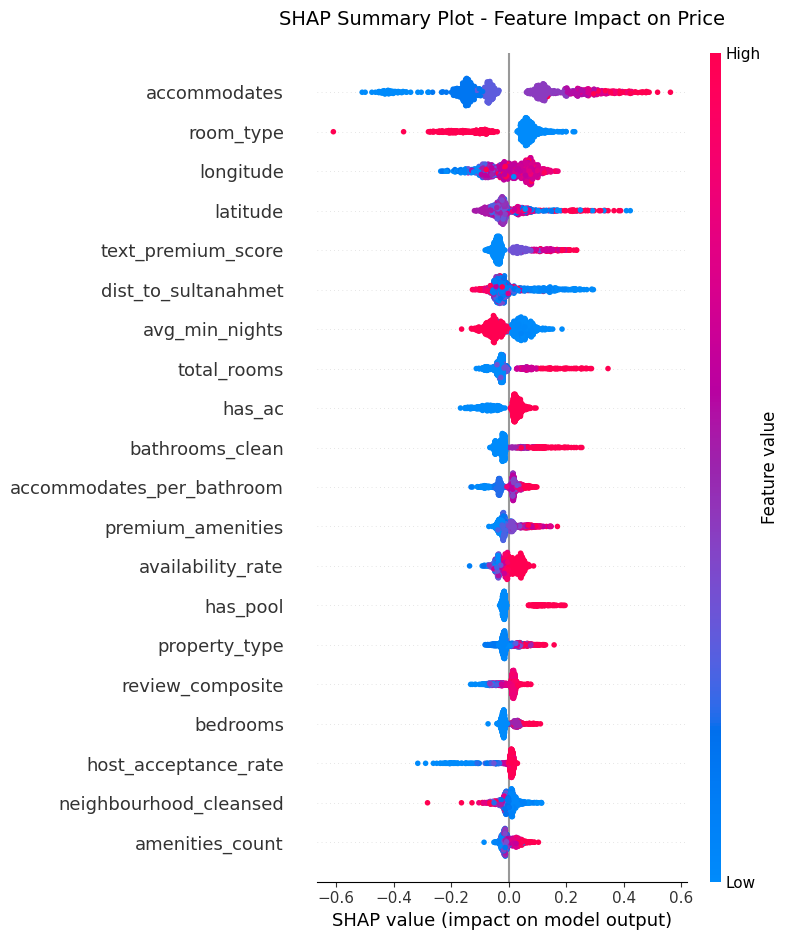

In [10]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.title("SHAP Summary Plot - Feature Impact on Price", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SHAP Bar Plot (Feature Importance)

Mean |SHAP value| - her feature'ın ortalama mutlak etkisi

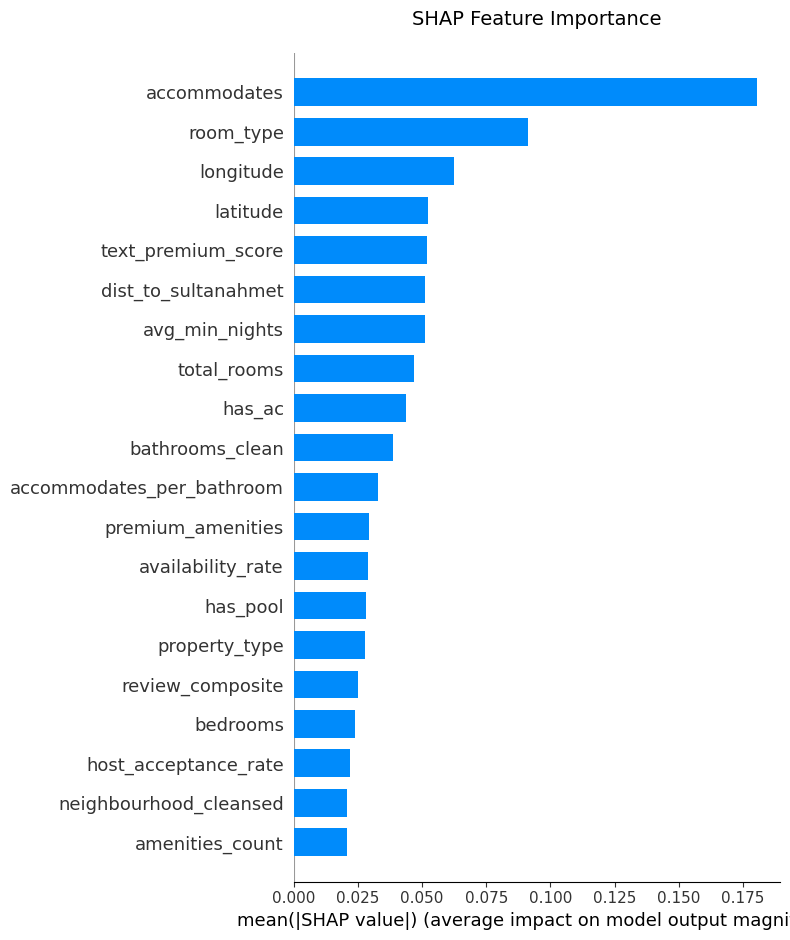

In [11]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top 15 Features by SHAP

In [23]:
feature_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

feature_importance.head(15)

,feature,mean_shap
11,accommodates,0.180343
10,room_type,0.091300
8,longitude,0.062442
7,latitude,0.052143
68,text_premium_score,0.051882
18,dist_to_sultanahmet,0.051285
41,avg_min_nights,0.051154
74,total_rooms,0.046939
24,has_ac,0.043670
20,bathrooms_clean,0.038858


## 7. SHAP Dependence Plots

Top 4 feature için: X ekseni feature değeri, Y ekseni SHAP değeri

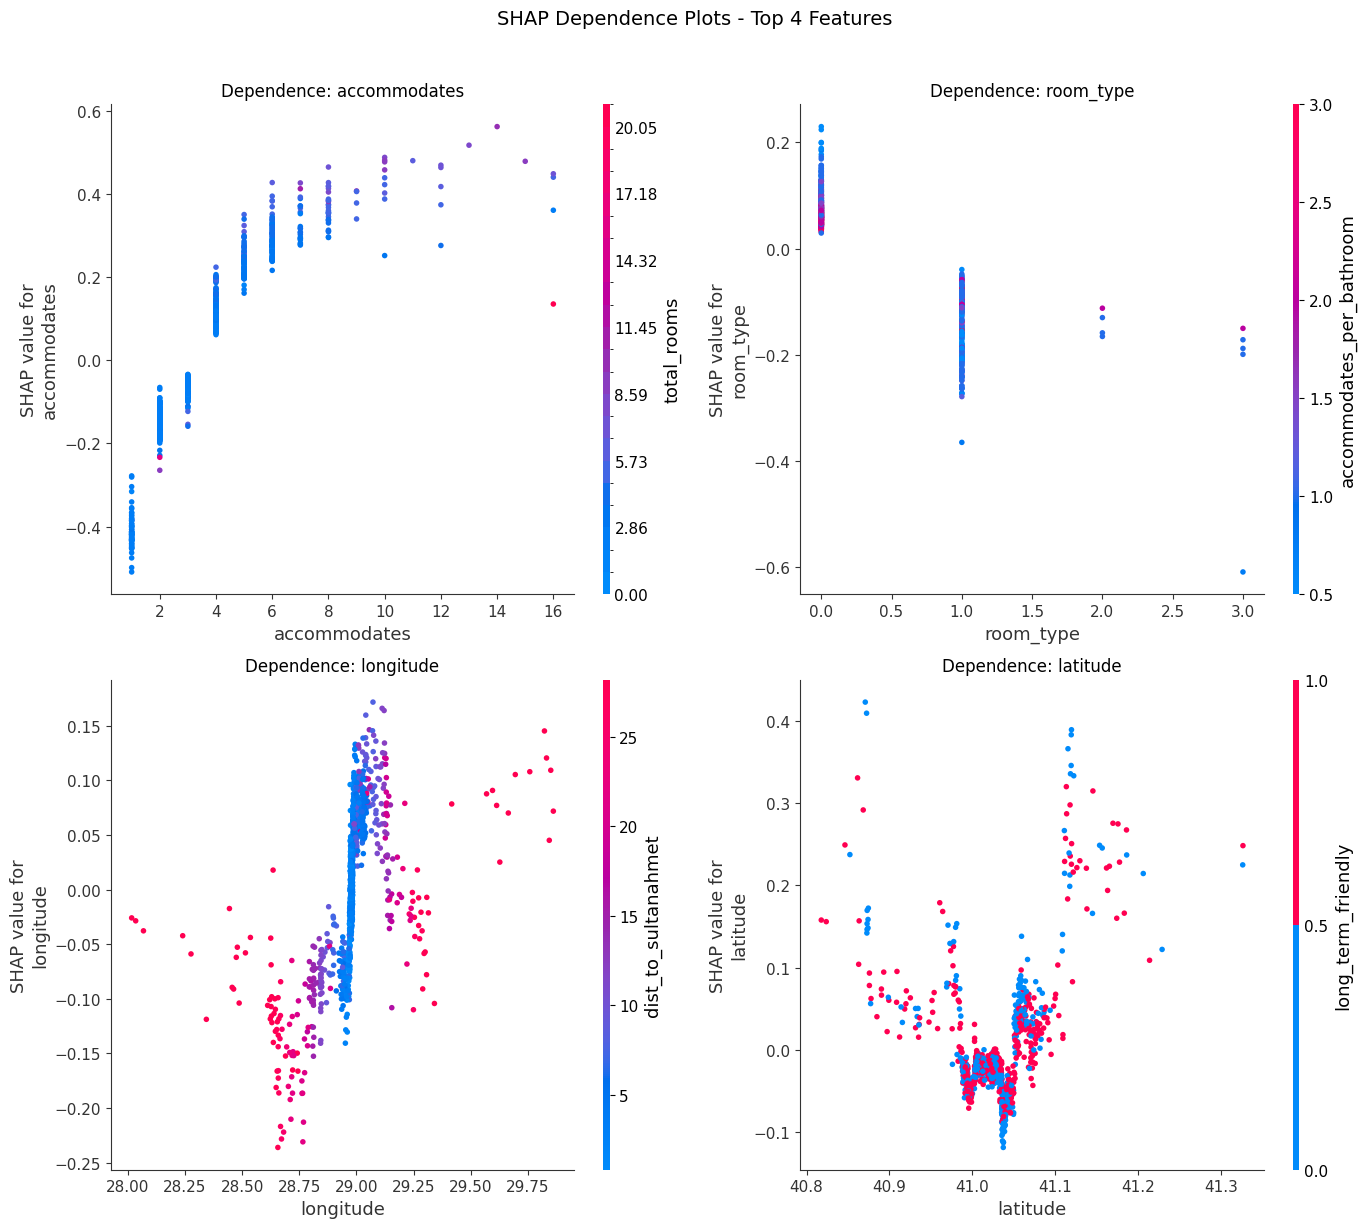

In [14]:
# top 4 feature
top_features = feature_importance.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, feature in enumerate(top_features):
    ax = axes[idx // 2, idx % 2]
    shap.dependence_plot(
        feature, 
        shap_values, 
        X_sample, 
        ax=ax, 
        show=False
    )
    ax.set_title(f"Dependence: {feature}", fontsize=12)

plt.suptitle("SHAP Dependence Plots - Top 4 Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Waterfall Plot - Tek Tahmin Açıklaması

Bir listing için fiyat tahmininin nasıl oluştuğunu gösterir.

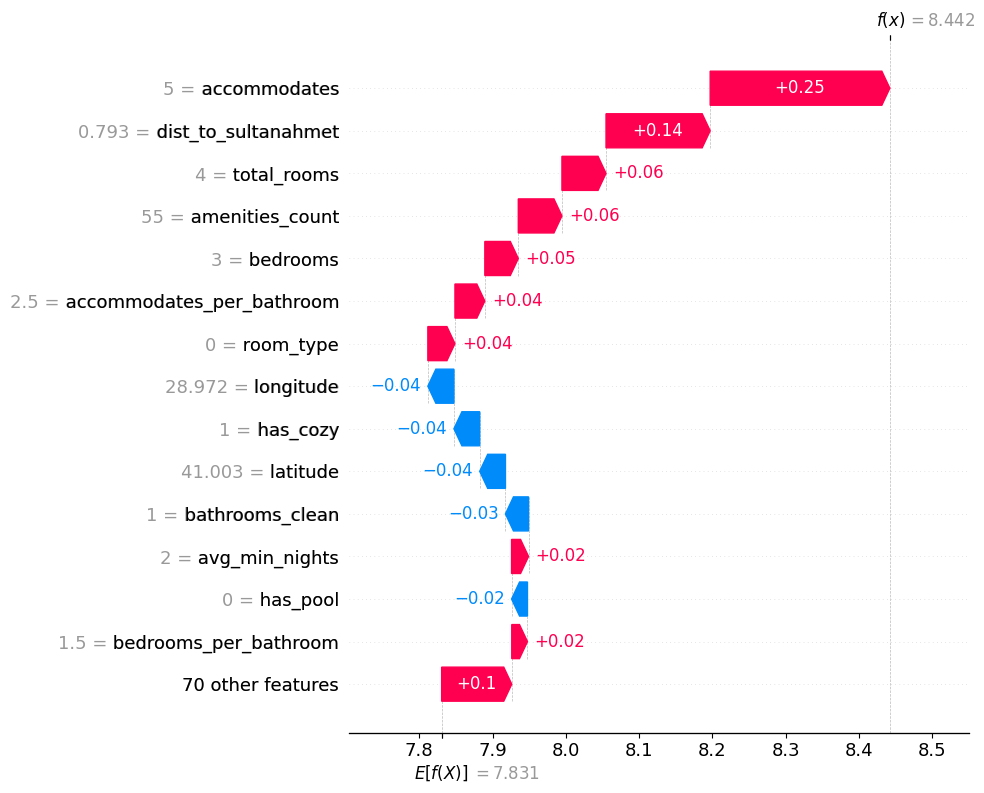

<Figure size 640x480 with 0 Axes>

In [15]:
# İlk örnek için waterfall
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0], 
        base_values=explainer.expected_value, 
        data=X_sample.iloc[0],
        feature_names=X_sample.columns.tolist()
    ), 
    max_display=15
)
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')

## 9. Force Plot

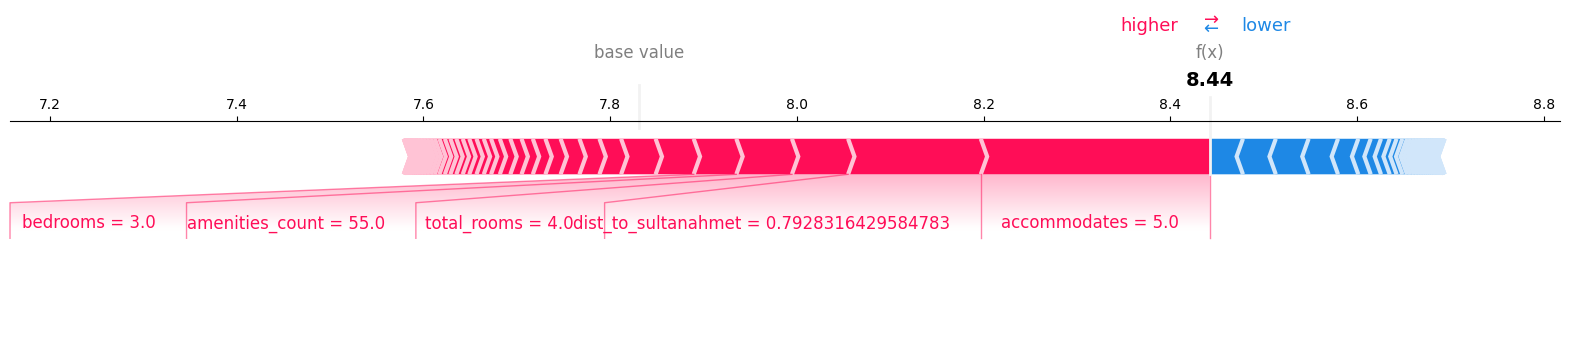

<Figure size 640x480 with 0 Axes>

In [16]:
# Tek bir tahmin için force plot
shap.force_plot(
    explainer.expected_value, 
    shap_values[0], 
    X_sample.iloc[0],
    matplotlib=True
)
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')

## 10. Key Insights

### Bulgular:

1. **accommodates**: En önemli feature - kapasite arttıkça fiyat artıyor
2. **total_rooms**: Toplam oda sayısı fiyatı direkt etkiliyor
3. **room_type**: Entire home/apt vs Private room büyük fark yaratıyor
4. **bathrooms_clean**: Banyo sayısı premium göstergesi
5. **has_ac**: Klima varlığı fiyatı artırıyor
6. **text_premium_score**: Açıklamadaki "Bosphorus", "sea view" gibi kelimeler fiyatı yükseltiyor
7. **dist_to_sultanahmet**: turistik yere yakınlık önemli

### Model Yorumlanabilirliği:
- SHAP değerleri modelin "black box" olmadığını gösteriyor
- Her tahmin için açıklama yapılabilir
- Feature engineering kararlarımız doğrulandı